In [27]:
# for datasets in sim 3- counts are generated so that the ratios are close the real data noise level 2 

In [1]:
import os
from pathlib import Path
import sys
import numpy as np
import scvelo as scv

In [2]:
notebook_dir = os.getcwd()
notebook_dir

'c:\\Users\\OmerCagatayTalikaci\\Desktop\\github\\STVelo\\notebooks\\analysis\\noise_effects'

In [3]:
Path(notebook_dir).parents[3]

WindowsPath('c:/Users/OmerCagatayTalikaci/Desktop/github')

In [4]:
os.chdir(Path(notebook_dir).parents[3])

In [5]:
stvelo_path = os.path.join(os.getcwd(),'STVelo','stvelo')

import sys  
sys.path.insert(1,stvelo_path)

from pipelines.metrics import *
from pipelines.utils import proportions_nuc_cyto

# Read adatas 

In [6]:
adata_folder_path = os.path.join(os.getcwd(), 'data', 'noise_1') 

In [7]:
import os
import anndata as ad


# Initialize an empty dictionary to store the AnnData objects
adata_dict = {}

# Loop through all files in the folder
for file_name in os.listdir(adata_folder_path):
    # Check if the file has .h5ad extension
    if file_name.endswith('.h5ad'):
        # Remove the file extension to use as the dictionary key
        key = os.path.splitext(file_name)[0]
        
        # Read the .h5ad file and store it in the dictionary
        adata_dict[key] = scv.read(os.path.join(adata_folder_path, file_name))

# Now, adata_dict contains the .h5ad files with keys as their filenames without extension


In [8]:
adatas = {k:v.copy() for k,v in adata_dict.items()}

In [8]:
import matplotlib.pyplot as plt 

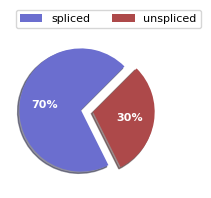

In [13]:
scv.pl.proportions(adata_dict['adata_s_u_800obs_300genes_dynamical'])

<Axes: >

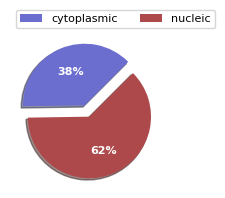

In [11]:
proportions_nuc_cyto(adata_dict['adata_random_800obs_300_genes_deterministic'])

<Axes: >

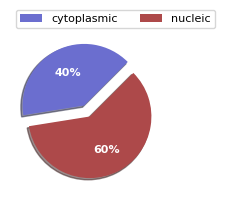

In [12]:
proportions_nuc_cyto(adata_dict['adata_n_c_800obs_300genes_deterministic'])

# Metrics 

# Confidence 

- Confidence metric measures the mean velocity consistency by calculating the pearson correlation between a cell and its neighbours. Let $v(x_j)$ be the velocity of cell $x_j$. Confidence $c_j$ is given by;

$$c_j = \frac{1}{k} \sum_{x \in \mathit{N_k(x_j)} } corr(v(x_j),v(x))$$

where $\mathit{N_k(x_j)}$ is the k-neighbours of $x_j$ in KNN graph.


sc.pp.neighbors(adata) > scv.tl.velocity() > scv.tl.velocity_graph() to compute cosine corr. > scv.tl.velocity_confidence()

In [15]:
adata_dict.pop('adata_random_800obs_300_genes_dynamical')

AnnData object with n_obs × n_vars = 800 × 300
    obs: 'n_counts', 'leiden'
    var: 'n_cells', 'fit_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'velocity_genes'
    uns: 'leiden', 'log1p', 'neighbors', 'pca', 'recover_dynamics', 'umap', 'velocity_params'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs', 'loss'
    layers: 'Ms', 'Mu', 'fit_t', 'fit_tau', 'fit_tau_', 'spliced', 'unspliced', 'velocity', 'velocity_u'
    obsp: 'connectivities', 'distances'

In [16]:
for d in adata_dict.keys():
    print(d)
    adata_dict[d]=compute_confidence(adata_dict[d])

adata_n_c_1000obs_300genes_deterministic
computing velocity graph (using 2/24 cores)
    finished (0:00:10) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
adata_n_c_1000obs_300genes_dynamical
computing velocity graph (using 2/24 cores)
    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
adata_n_c_1000obs_300genes_stochastic
computing velocity graph (using 2/24 cores)
    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
adata_n_c_800obs_300genes_deterministic
computing velocity graph (using 2/24 cores)
    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations 

<Axes: xlabel='Velocity confidence', ylabel='velo_type'>

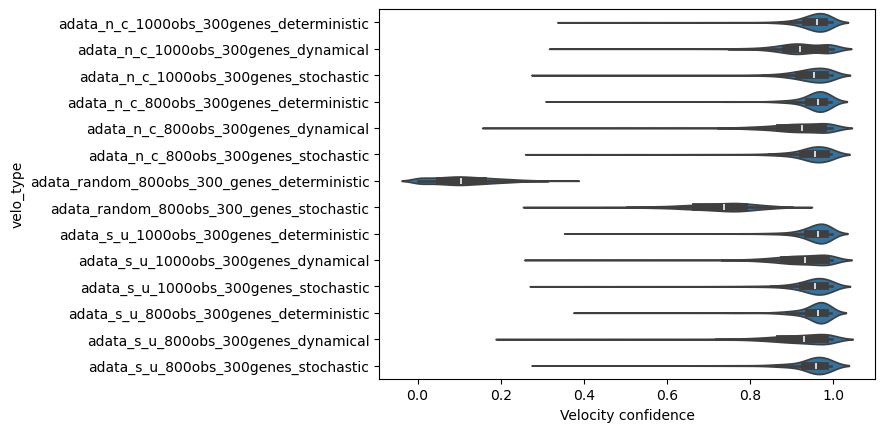

In [17]:
import seaborn as sns
confidences=get_confidences(adata_dict)
sns.violinplot(data=confidences,x='Velocity confidence',y='velo_type')

## Velocity length for different leiden clusters  

In [39]:
adata_dict['adata_n_c_800obs_300genes_deterministic'].obs.groupby('leiden')['velocity_length'].mean()

leiden
0     542.199036
1     769.663879
2    1074.399048
3     804.050293
4     845.664734
5     710.442749
6     911.945068
7    1068.209717
Name: velocity_length, dtype: float32

In [40]:
adata_dict['adata_s_u_800obs_300genes_deterministic'].obs.groupby('leiden')['velocity_length'].mean()

leiden
0    298.846710
1    422.579742
2    607.991272
3    378.166412
4    477.971191
5    384.440674
6    458.623199
7    597.789307
Name: velocity_length, dtype: float32

# Velocity Correlation by gene

Checks if the velocities calculated for the same gene in different modalities are consistent. 

In [18]:
adata_800 = {'adata_n_c_800obs_300genes_deterministic': adata_dict['adata_n_c_800obs_300genes_deterministic'].copy(),
             'adata_s_u_800obs_300genes_deterministic': adata_dict['adata_s_u_800obs_300genes_deterministic'].copy(),
             'adata_n_c_800obs_300genes_dynamical': adata_dict['adata_n_c_800obs_300genes_dynamical'],
             'adata_n_c_800obs_300genes_stochastic':  adata_dict['adata_n_c_800obs_300genes_stochastic'],
             'adata_s_u_800obs_300genes_dynamical': adata_dict['adata_s_u_800obs_300genes_dynamical'],
            'adata_s_u_800obs_300genes_stochastic': adata_dict['adata_s_u_800obs_300genes_stochastic'],
             'adata_random_800obs_300_genes_deterministic': adata_dict['adata_random_800obs_300_genes_deterministic'],
             'adata_random_800obs_300_genes_stochastic': adata_dict['adata_random_800obs_300_genes_stochastic']
             }

In [19]:
velocity_correlation_by_gene=velocity_corr_against_reference(adata_800,reference='adata_s_u_800obs_300genes_deterministic', mode= 'by_gene')

In [20]:
velocity_correlation_by_gene

,0,1,2,3,4,5,6,7,8,9,...,290,291,292,293,294,295,296,297,298,299
adata_n_c_800obs_300genes_deterministic,0.986140,0.990834,0.978008,0.996867,0.976797,0.997183,0.991080,0.981843,0.997285,0.984947,...,0.940020,0.988386,0.982872,0.947209,0.982136,0.970263,0.974850,0.996455,0.982968,0.993720
adata_s_u_800obs_300genes_deterministic,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
adata_n_c_800obs_300genes_dynamical,0.786876,0.839548,0.847578,0.908247,0.878344,0.849561,0.749706,0.024026,NaN,0.778487,...,0.679829,0.753830,0.844524,0.735974,0.821797,0.651963,0.631124,NaN,0.634874,NaN
adata_n_c_800obs_300genes_stochastic,0.985833,0.991571,0.972474,0.994741,0.954254,0.994422,0.990059,0.982121,0.997285,0.978244,...,0.940091,0.923903,0.982508,0.842831,0.978085,0.956819,0.947649,0.996455,0.981489,0.993720
adata_s_u_800obs_300genes_dynamical,0.930957,0.816656,0.915587,0.815709,0.930977,0.921336,0.834049,0.116038,0.831787,0.718581,...,0.876159,0.697993,0.821001,0.847663,0.891103,0.916162,0.699686,0.908712,NaN,NaN
adata_s_u_800obs_300genes_stochastic,0.999900,0.999978,0.998866,0.999887,0.996855,0.999110,0.999830,0.998976,0.999999,0.999372,...,0.992160,0.979600,0.999960,0.934138,0.999480,0.971841,0.990558,0.998806,1.000000,1.000000
adata_random_800obs_300_genes_deterministic,0.045474,0.062665,0.034552,0.030292,0.014070,-0.009221,0.013229,-0.075204,-0.030427,-0.024808,...,-0.011904,-0.013867,-0.025918,0.001564,0.011799,-0.007011,-0.002111,0.049998,-0.000840,-0.080729
adata_random_800obs_300_genes_stochastic,0.054213,0.062665,0.034552,0.030292,0.001371,-0.009221,0.013178,-0.075204,-0.030427,-0.034041,...,-0.011904,-0.017050,-0.025918,0.001564,0.011799,-0.007011,-0.002111,0.049998,-0.000840,-0.080729


Text(0, 0.5, 'Modality')

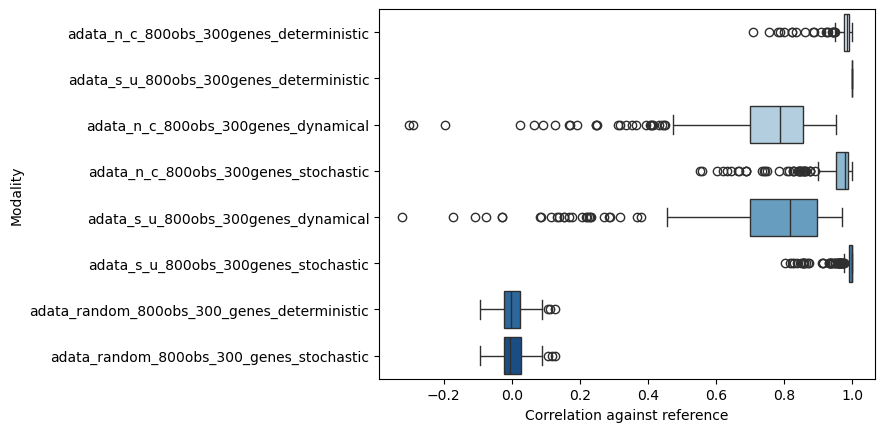

In [57]:
# velocity corr against a reference 
# import matplotlib.pyplot as plt
# sns.clustermap(velocity_correlation_by_gene.fillna(0),figsize=(7,4),cmap='Blues')
# sns.scatterplot(velocity_correlation_by_gene[:1].T)
# plt.figure(figsize=(5,5))
sns.boxplot(data=velocity_correlation_by_gene.iloc[[0,1,2,3,4,5,6,7]].stack().reset_index(),y='level_0',x=0,palette='Blues')
plt.xlabel('Correlation against reference')
plt.ylabel('Modality')


- It looks like the model capture more or less the same dynamics for the genes in two modalities. Investigate lover correlations:

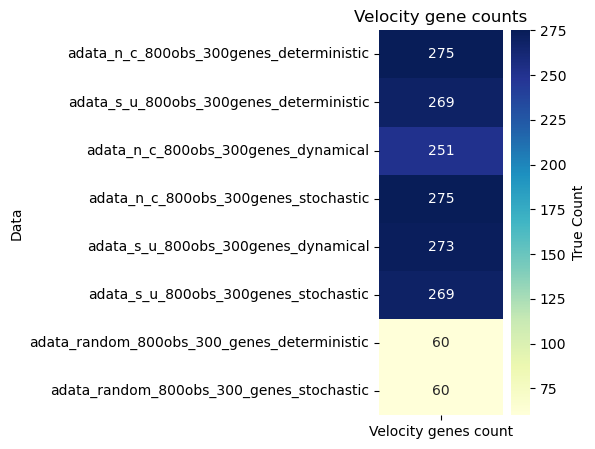

In [ ]:
true_counts = {}
for name, adata in adata_800.items():
    true_counts[name] = adata.var['velocity_genes'].value_counts().get(True, 0)  # Get count of True or 0 if not present

true_counts_df = pd.DataFrame.from_dict(true_counts, orient='index', columns=['Velocity genes count'])

pd.set_option('display.float_format', '{:,.0f}'.format)
# Plot the heatmap
plt.figure(figsize=(2, 5))
sns.heatmap(true_counts_df, annot=True, cmap='YlGnBu', cbar_kws={'label': 'True Count'},fmt='g')
plt.title('Velocity gene counts')
plt.ylabel('Data')
plt.show()

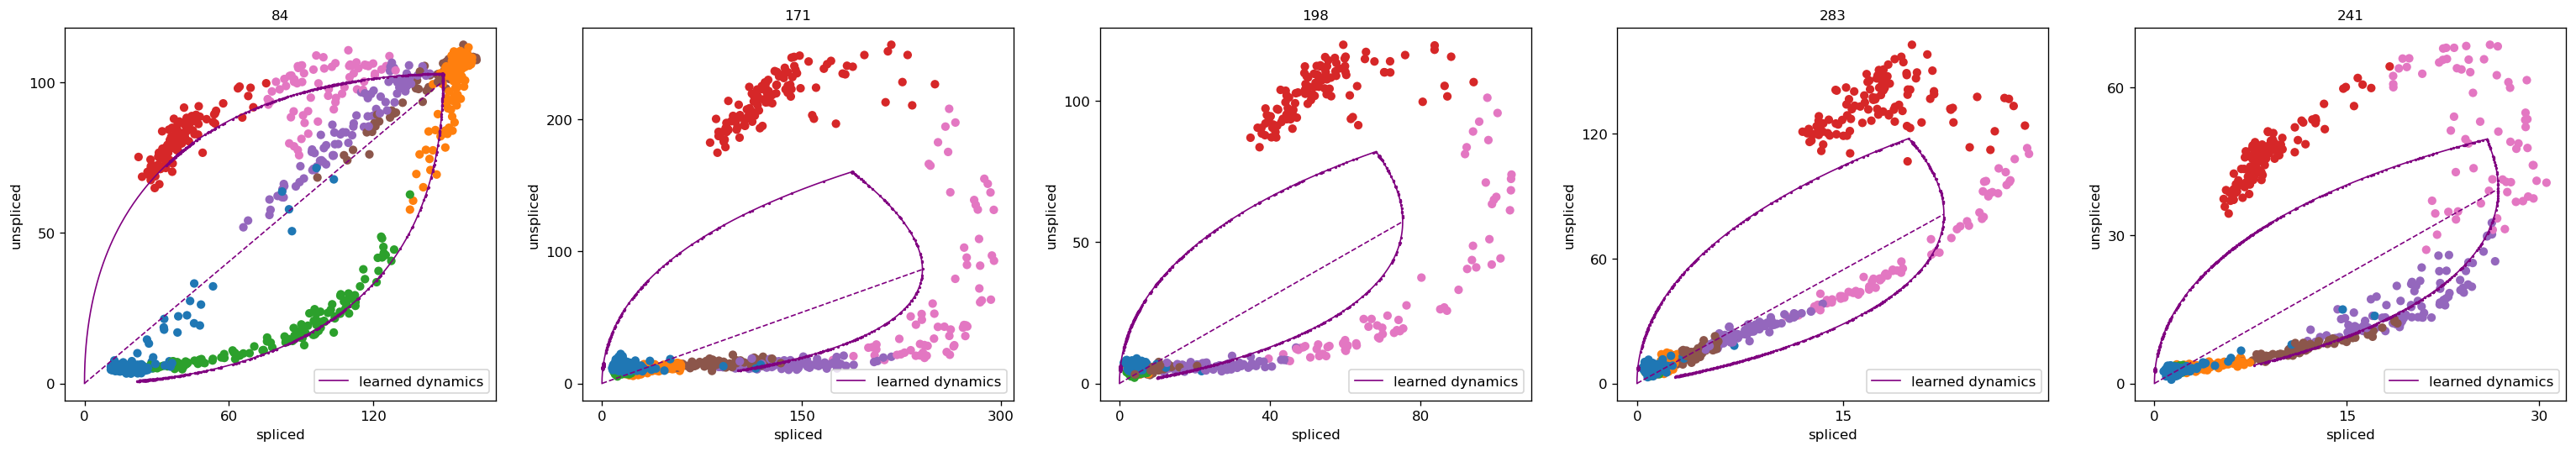

In [52]:
scv.pl.scatter(adata_dict['adata_n_c_800obs_300genes_dynamical'],color="leiden", basis=['84','171','198','283','241'], ncols=5, frameon=True,dpi=120,)

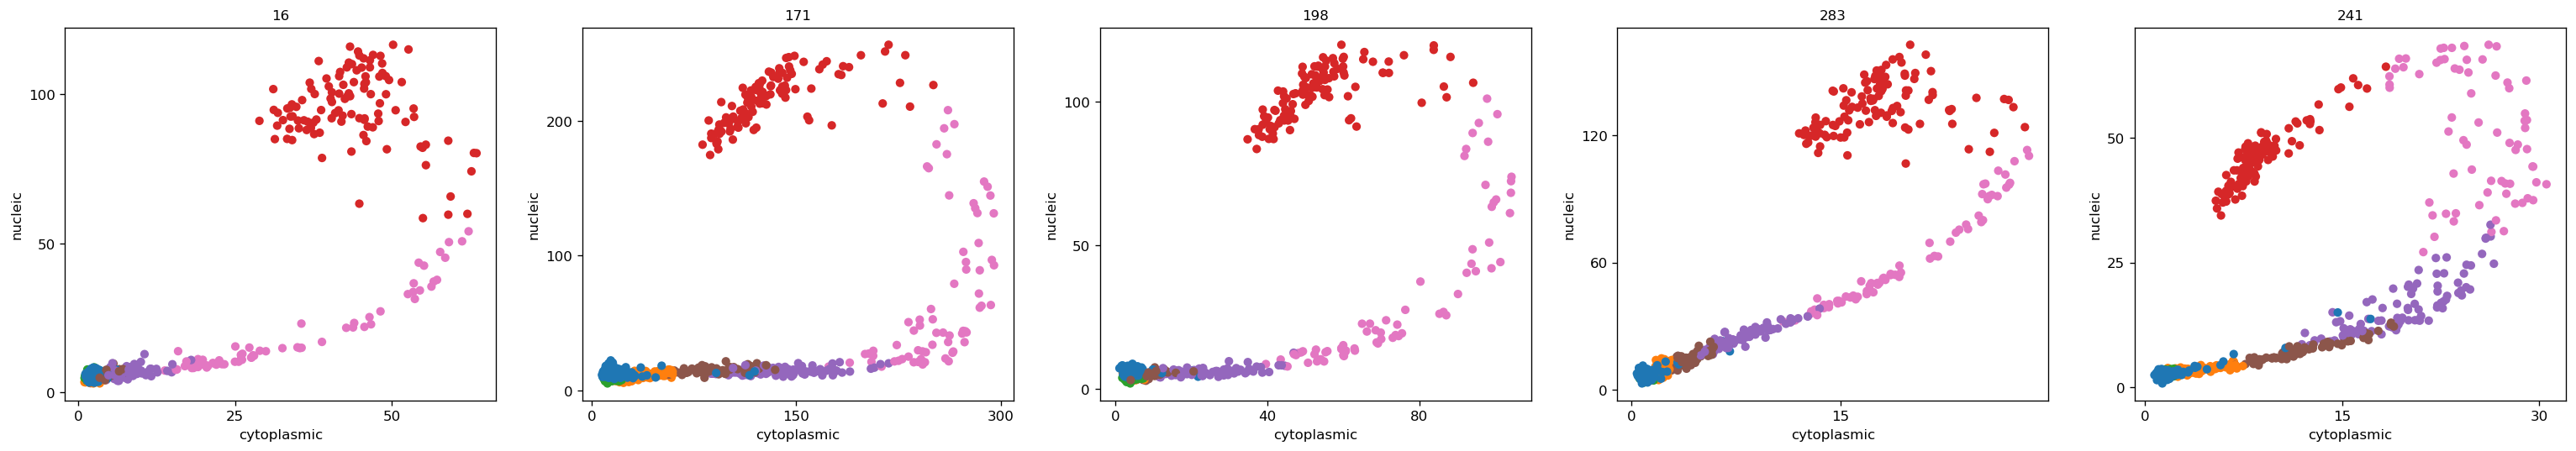

In [53]:
scv.pl.scatter(adata_dict['adata_n_c_800obs_300genes_dynamical'],color="leiden", basis=['16','171','198','283','241'], ncols=5, frameon=True,dpi=120, xlabel='cytoplasmic', ylabel='nucleic', vkey='velocity')

# Velocity correlation by cell 

In [41]:
velocity_correlation_by_cell=velocity_corr_against_reference(adata_800,reference='adata_s_u_800obs_300genes_deterministic', mode= 'by_cell')

Text(0.5, 0, 'Correlation against reference')

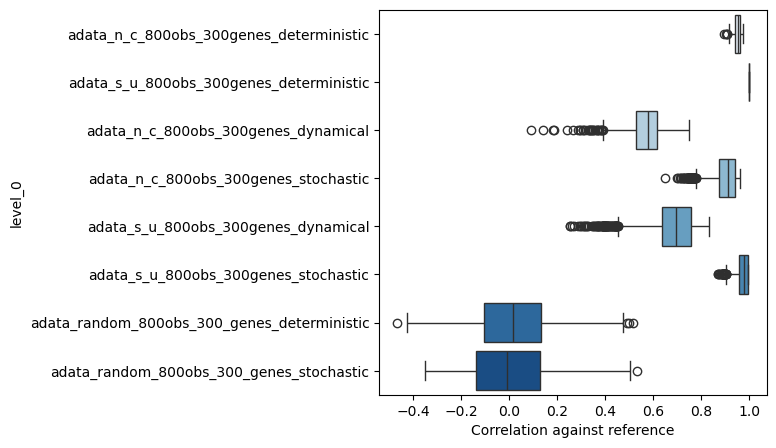

In [42]:
# same, but by cell
import matplotlib.pyplot as plt
# sns.clustermap(velocity_correlation_by_cell.fillna(0),figsize=(7,4),cmap='Blues')
plt.figure(figsize=(5,5))
sns.boxplot(data=velocity_correlation_by_cell.stack().reset_index(),y='level_0',x=0,palette='Blues')
plt.xlabel('Correlation against reference')

In [43]:
adata_800['adata_n_c_800obs_300genes_deterministic']

AnnData object with n_obs × n_vars = 800 × 300
    obs: 'true_t', 'n_counts', 'leiden', 'velocity_self_transition', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition', 'Velocity confidence'
    var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling', 'n_cells', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
    uns: 'leiden', 'log1p', 'neighbors', 'pca', 'umap', 'velocity_graph', 'velocity_graph_neg', 'velocity_params'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'spliced', 'spliced_nuc', 'true_velocity', 'unspliced', 'velocity'
    obsp: 'connectivities', 'distances'

In [93]:
leiden_s_u = adata_800['adata_s_u_800obs_300genes_deterministic'].obs['leiden']
velocity_conf_n_c = adata_800['adata_n_c_800obs_300genes_deterministic'].obs['velocity_confidence']
velocity_conf_s_u = adata_800['adata_s_u_800obs_300genes_deterministic'].obs['velocity_confidence']

In [94]:
velo_corr_cell = pd.DataFrame(velocity_correlation_by_cell.T)
velo_corr_cell['leiden'] = leiden_s_u 
velo_corr_cell['velocity_conf_n_c'] = velocity_conf_n_c
velo_corr_cell['velocitty_conf_s_u'] = velocity_conf_s_u


In [57]:
scv.tl.velocity_graph(adata_dict['adata_random_deterministic'])

computing velocity graph (using 1/24 cores)
    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


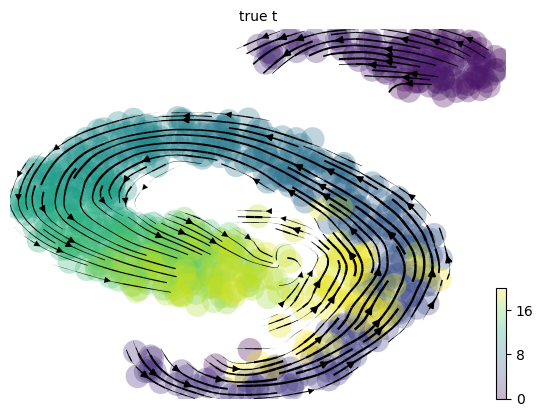

In [61]:
scv.pl.velocity_embedding_stream(adata_dict['adata_s_u_800obs_300genes_deterministic'], basis='umap', color='true_t')

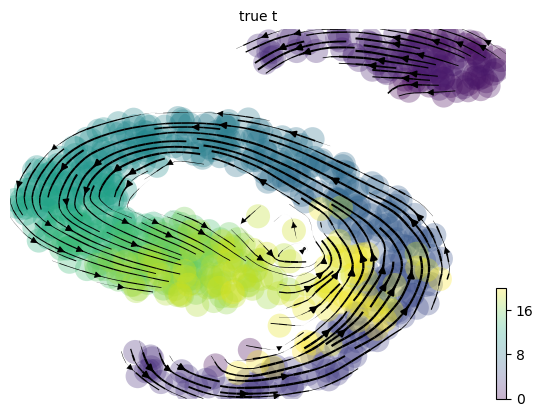

In [59]:
scv.pl.velocity_embedding_stream(adata_dict['adata_n_c_800obs_300genes_dynamical'], basis='umap', color='true_t')

computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


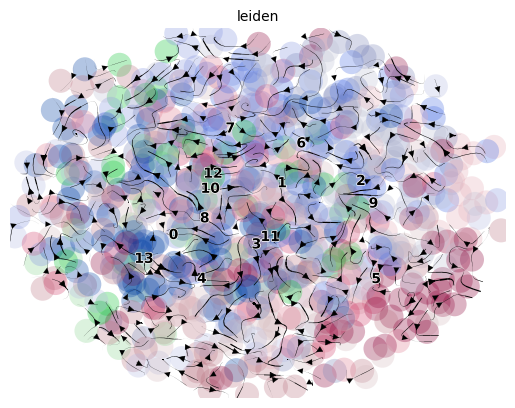

In [45]:
scv.pl.velocity_embedding_stream(adata_dict['adata_random_800obs_300_genes_deterministic'], basis='umap', color='leiden')

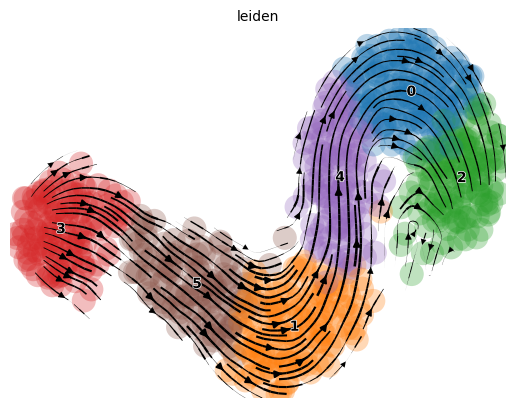

In [106]:
scv.pl.velocity_embedding_stream(adata_n_c_800obs, basis='umap', color='leiden')

# Velocity Confidence

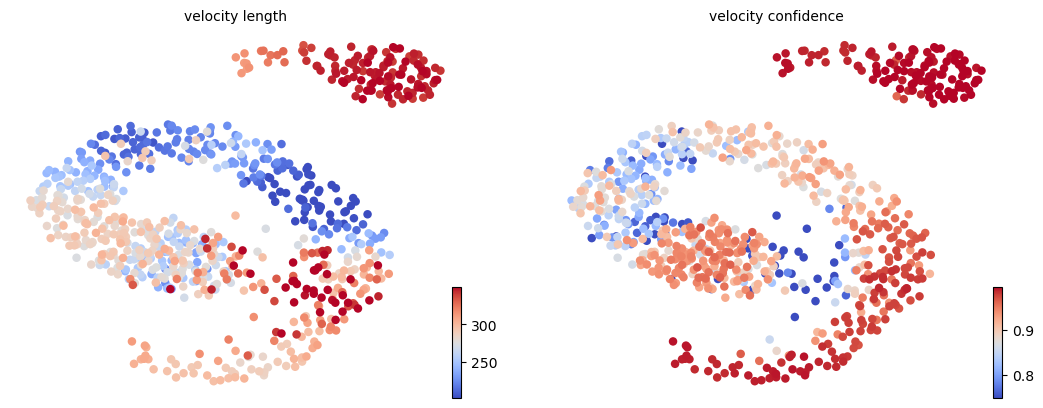

In [56]:
keys = 'velocity_length', 'velocity_confidence'
scv.pl.scatter(adata_dict['adata_n_c_800obs_300genes_dynamical'], c=keys, cmap='coolwarm', perc=[5, 95])

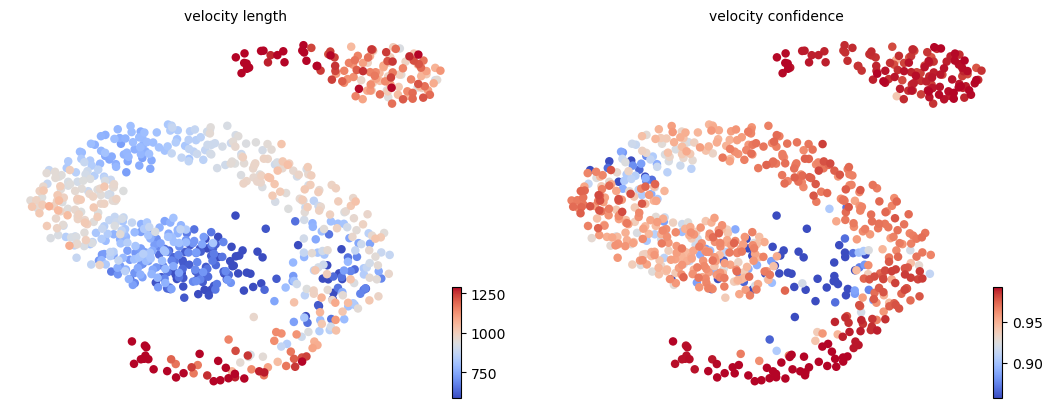

In [ ]:
keys = 'velocity_length', 'velocity_confidence'
scv.pl.scatter(adata_dict['adata_n_c_800obs_300genes_deterministic'], c=keys, cmap='coolwarm', perc=[5, 95])

--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)


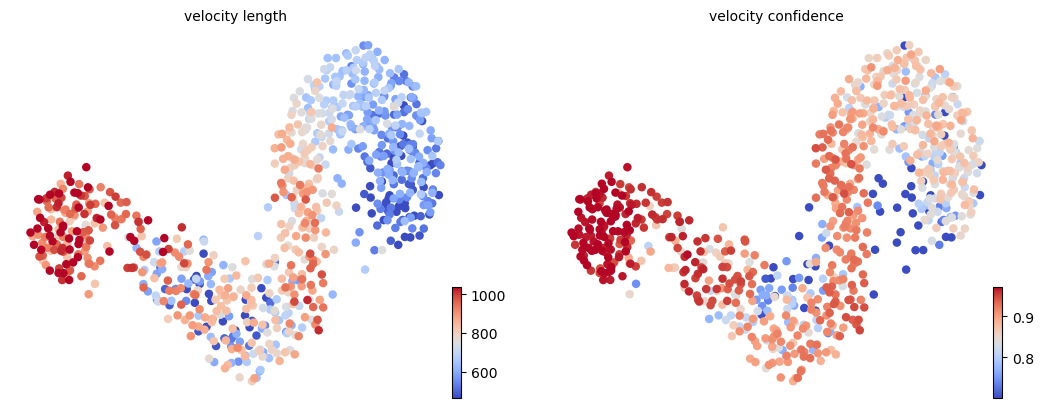

In [112]:
scv.tl.velocity_confidence(adata_n_c_800obs)
keys = 'velocity_length', 'velocity_confidence'
scv.pl.scatter(adata_n_c_800obs, c=keys, cmap='coolwarm', perc=[5, 95])

# Sign Accuracy 

In [116]:
adata_800['random'] = adata_random

In [117]:
scv.pp.moments(adata_800['random'], n_pcs=None, n_neighbors=None)
scv.tl.velocity_graph(adata_800['random'])

computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocity graph (using 1/24 cores)
    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


In [48]:
adata_dict['adata_random_800obs_300_genes_deterministic'].obs['true_t'] = adata_dict['adata_s_u_800obs_300genes_deterministic'].obs['true_t'] 
adata_dict['adata_random_800obs_300_genes_stochastic'].obs['true_t'] = adata_dict['adata_s_u_800obs_300genes_deterministic'].obs['true_t'] 

In [47]:
adata_dict['adata_n_c_1000obs_300genes_deterministic']

AnnData object with n_obs × n_vars = 1000 × 300
    obs: 'true_t', 'n_counts', 'leiden', 'velocity_self_transition', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition', 'Velocity confidence'
    var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling', 'n_cells', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
    uns: 'leiden', 'log1p', 'neighbors', 'pca', 'umap', 'velocity_graph', 'velocity_graph_neg', 'velocity_params'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'spliced', 'spliced_nuc', 'true_velocity', 'unspliced', 'velocity'
    obsp: 'connectivities', 'distances'

In [49]:
sign_accuracies=get_sign_accuracy(adata_dict)

adata_n_c_1000obs_300genes_deterministic


100%|██████████| 785/785 [00:00<00:00, 22053.84it/s]


adata_n_c_1000obs_300genes_dynamical


100%|██████████| 785/785 [00:00<00:00, 19592.32it/s]


adata_n_c_1000obs_300genes_stochastic


...

100%|██████████| 656/656 [00:00<00:00, 17774.20it/s]


adata_s_u_800obs_300genes_dynamical


100%|██████████| 656/656 [00:00<00:00, 17179.04it/s]


adata_s_u_800obs_300genes_stochastic


100%|██████████| 656/656 [00:00<00:00, 15184.51it/s]


<Axes: xlabel='Accuracy', ylabel='Model'>

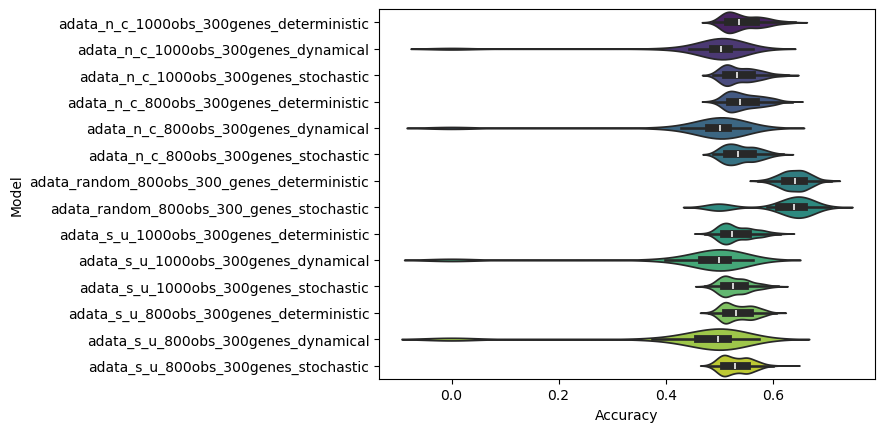

In [50]:
sns.violinplot(data=sign_accuracies,y='Model',x='Accuracy',palette='viridis')